In [1]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("spearman_duplicates_grouped_norepeat_Specificity_model_mlp.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q1 > 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("features_with_positive_IQR_Specificity_model_mlp.csv", index=False)


                               Feature     Q1     Q3  \
0                         crRNA spacer  0.922  0.982   
1  bh_maximal consecutive paired bases  0.937  0.970   
2                       bh_5' overhang  0.605  0.912   
3                           bh_3' stem  0.806  0.921   
4                         dsDNA target  0.997  0.997   
5                       ah_5' overhang  0.553  0.956   
6                       ah_3' overhang  0.646  0.834   
7                           ah_5' stem  0.750  0.779   
8                           ah_3' stem  0.221  0.792   

   Median Spearman Correlation  
0                        0.950  
1                        0.958  
2                        0.902  
3                        0.905  
4                        0.997  
5                        0.729  
6                        0.802  
7                        0.762  
8                        0.682  


/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_35710/1960053500.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


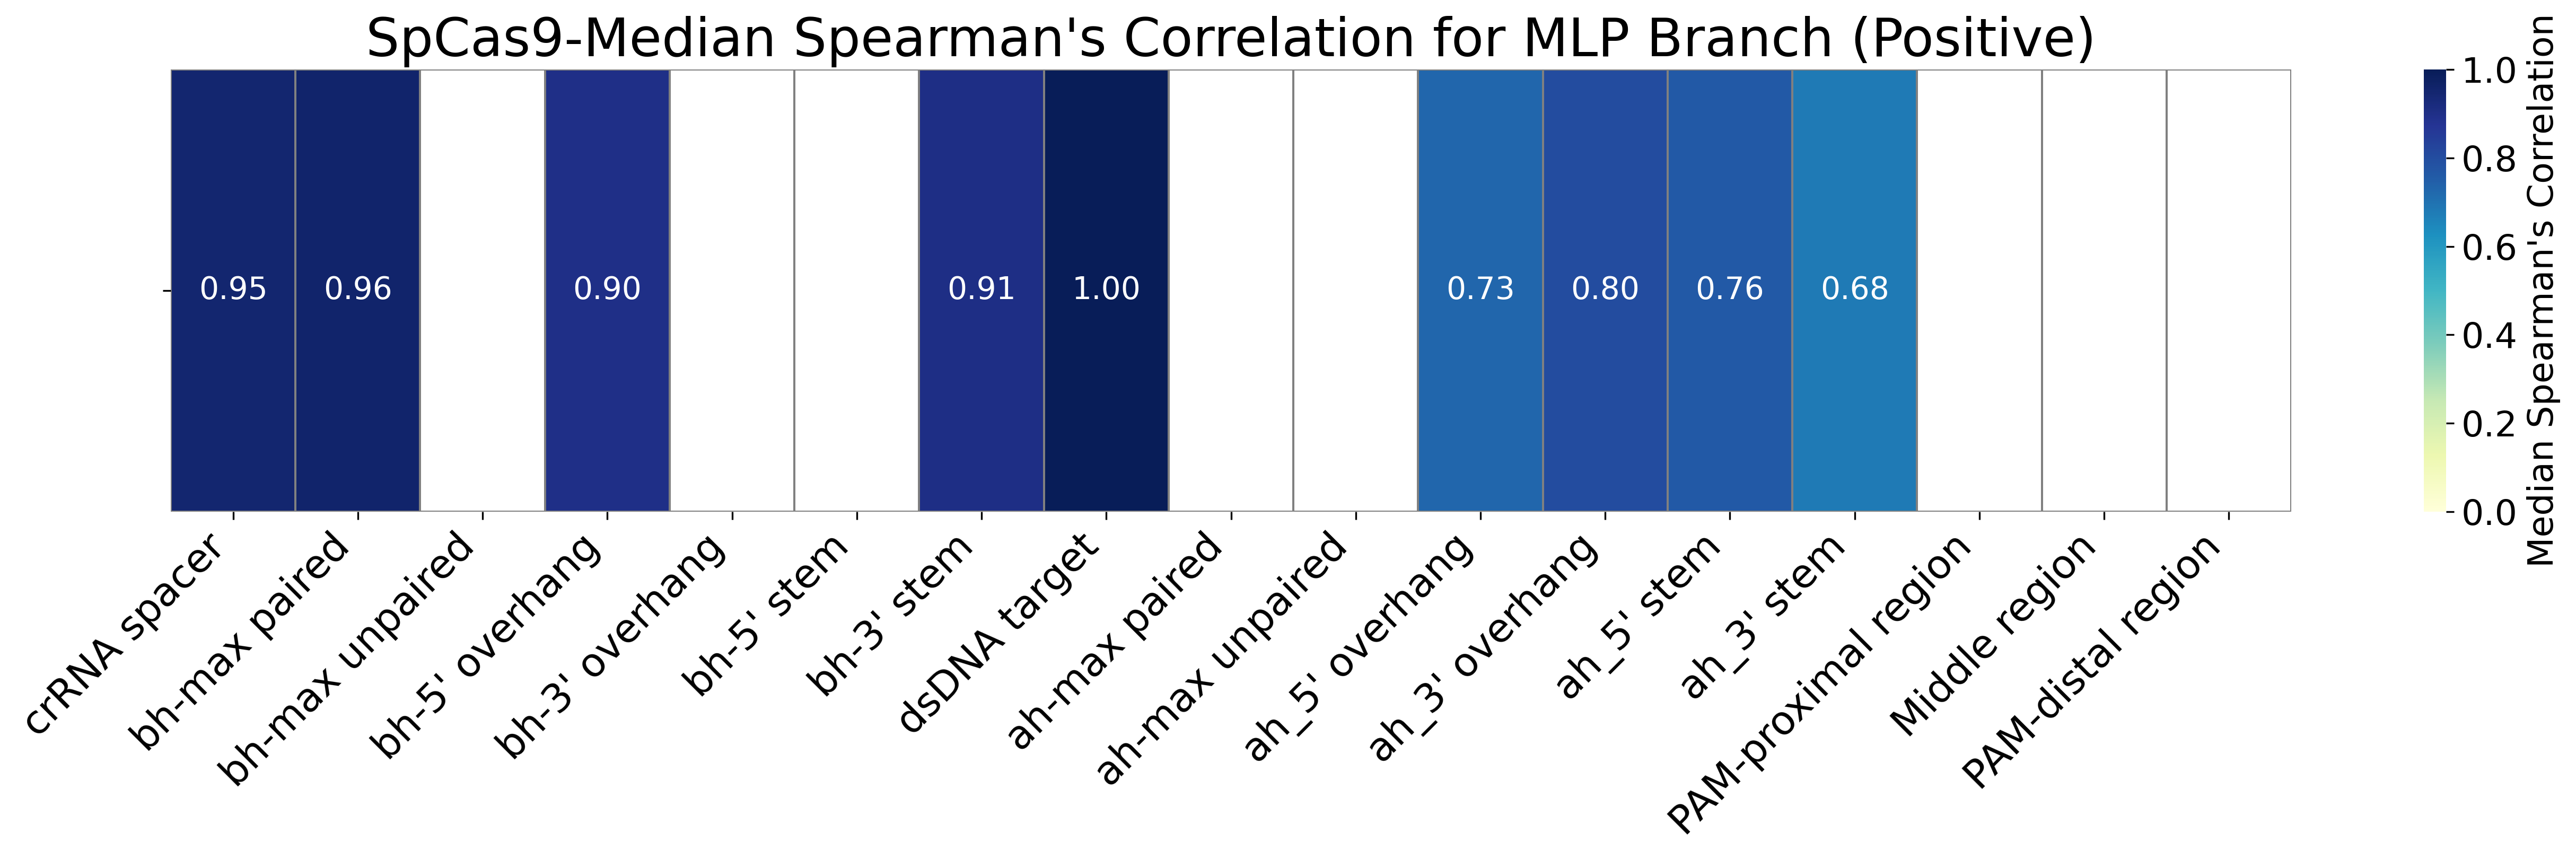

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---- desired full feature order (17 columns) ----
feature_order = [
    "crRNA spacer",
    "bh_maximal consecutive paired bases",
    "bh_maximal consecutive unpaired bases",
    "bh_5' overhang",
    "bh_3' overhang",
    "bh_5' stem",
    "bh_3' stem",
    "dsDNA target",
    "ah_maximal consecutive paired bases",
    "ah_maximal consecutive unpaired bases",
    "ah_5' overhang",
    "ah_3' overhang",
    "ah_5' stem",
    "ah_3' stem",
    "PAM-proximal region",
    "central region",
    "PAM-distal region"
]

csv_path = "features_with_positive_IQR_Specificity_model_mlp.csv"
value_col = "Median Spearman Correlation"   # change if your column name differs
feature_col = "Feature"                     # change if your feature-name column differs

# ---- load ----
df = pd.read_csv(csv_path)

# Optional: if duplicates exist, average them
df = df.groupby(feature_col, as_index=False)[value_col].mean()

# ---- build a 1x17 table: row label "MLP", columns are the 17 features ----
# Map available features into a Series indexed by Feature name
s = df.set_index(feature_col)[value_col]

# Reindex to force all 17 features to exist; missing -> NaN
s = s.reindex(feature_order)

heatmap_data = pd.DataFrame([s.values], index=[""], columns=feature_order)

# ---- plot (NaN will be blank if masked) ----
mask = heatmap_data.isna()

fig, ax = plt.subplots(figsize=(18, 5.5), dpi=300)
hm = sns.heatmap(
    heatmap_data,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Median Spearman's Correlation"},
    annot_kws={"fontsize": 14},
    ax=ax
)

ax.set_ylabel("")  # 1-row heatmap; optional
ax.set_xlabel("")
ax.set_title("SpCas9-Median Spearman's Correlation for MLP Branch (Positive)", fontsize=24)

# Rotate x tick labels + align to the right (NOTE: use set_xticklabels for alignment)
short_labels = [
    "crRNA spacer",
    "bh-max paired",
    "bh-max unpaired",
    "bh-5' overhang",
    "bh-3' overhang",
    "bh-5' stem",
    "bh-3' stem",
    "dsDNA target",
    "ah-max paired",
    "ah-max unpaired",
    "ah_5' overhang",
    "ah_3' overhang",
    "ah_5' stem",
    "ah_3' stem",
    "PAM-proximal region",
    "Middle region",
    "PAM-distal region"
]

ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=18)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

# Colorbar font sizes
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
cbar.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()


In [5]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("spearman_duplicates_grouped_norepeat_Specificity_model_cnn1.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q1 > 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("features_with_positive_IQR_Specificity_model_cnn1.csv", index=False)


    Feature     Q1     Q3  Median Spearman Correlation
0    Pos2_A  0.786  0.786                        0.786
1    Pos3_A  0.761  0.761                        0.761
2    Pos4_A  0.361  0.606                        0.422
3    Pos5_A  0.825  0.826                        0.825
4    Pos6_A  0.653  0.655                        0.655
5    Pos7_A  0.527  0.592                        0.592
6    Pos7_G  0.001  0.680                        0.340
7    Pos8_A  0.704  0.704                        0.704
8    Pos9_A  0.783  0.783                        0.783
9   Pos10_A  0.582  0.627                        0.627
10  Pos11_A  0.655  0.678                        0.678
11  Pos11_C  0.119  0.416                        0.300
12  Pos12_A  0.584  0.650                        0.635
13  Pos12_C  0.684  0.722                        0.704
14  Pos13_A  0.624  0.632                        0.628
15  Pos14_A  0.698  0.698                        0.698
16  Pos14_G  0.137  0.797                        0.592
17  Pos15_

/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_35710/166854562.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


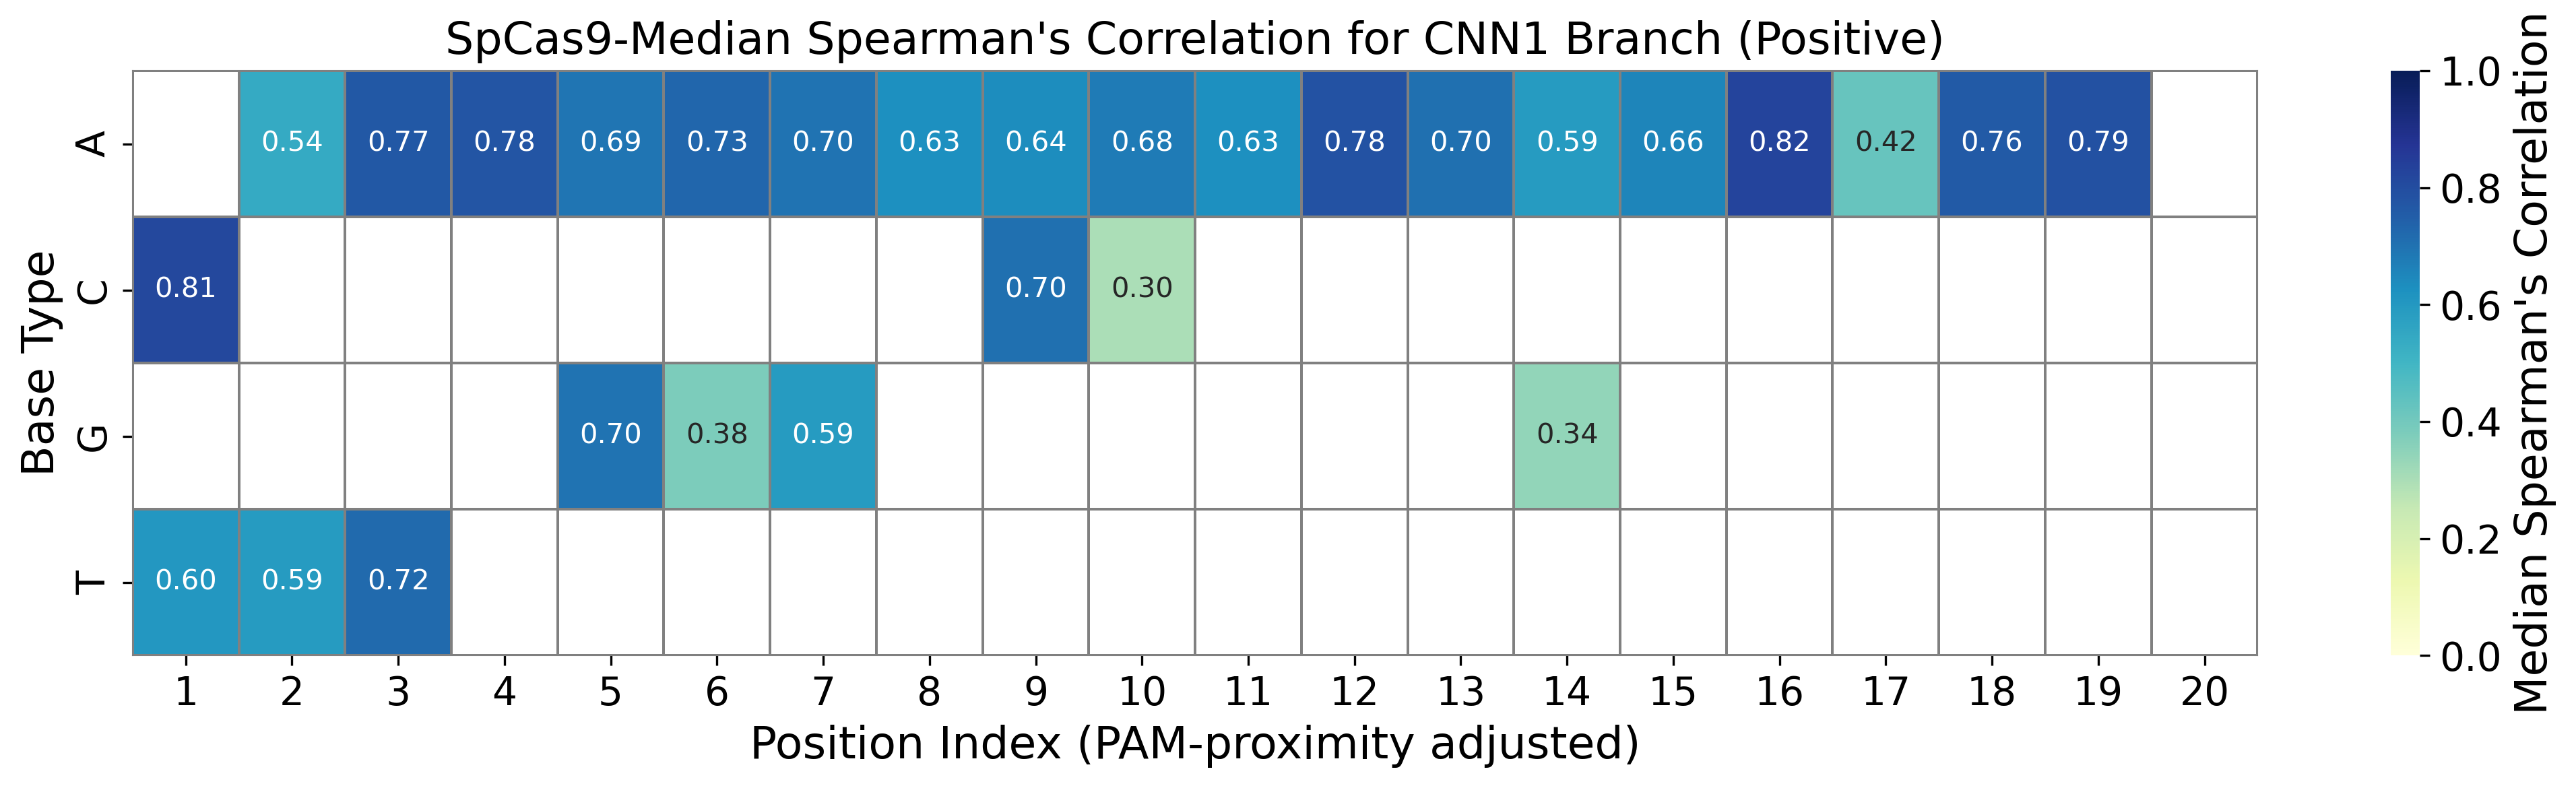

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load processed feature list
iqr_df = pd.read_csv("features_with_positive_IQR_Specificity_model_cnn1.csv")
iqr_df[['Pos', 'Base']] = iqr_df['Feature'].str.extract(r'Pos(\d+)_(\w)')
iqr_df['Pos'] = iqr_df['Pos'].astype(int)

# Pivot to heatmap format
heatmap_data = iqr_df.pivot(index="Base", columns="Pos", values="Median Spearman Correlation")

# Ensure all four bases are shown
base_order = ["A", "C", "G", "T"]
heatmap_data = heatmap_data.reindex(index=base_order)

# Ensure all 20 positions are shown, even if they have no values
heatmap_data = heatmap_data.reindex(columns=range(1, 21))

# Reverse columns for PAM-proximity adjustment
heatmap_data = heatmap_data.iloc[:, ::-1]

mask = heatmap_data.isna()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 4), dpi=300)
hm = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=mask,
    ax=ax
)

n_pos = heatmap_data.shape[1]
ax.set_xticks(np.arange(n_pos) + 0.5)
ax.set_xticklabels(range(1, n_pos + 1), fontsize=14)


# === Fix for missing bottom and right borders ===
# Turn on all spines (border lines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')


# Set custom font sizes
ax.set_xlabel("Position Index (PAM-proximity adjusted)", fontsize=16)
ax.set_ylabel("Base Type", fontsize=16)
ax.set_title("SpCas9-Median Spearman's Correlation for CNN1 Branch (Positive)", fontsize=16)

# Set tick label sizes
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# === Adjust colorbar font sizes ===
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  # Colorbar tick labels
cbar.set_label("Median Spearman's Correlation", fontsize=16)  # Colorbar title

plt.tight_layout()
plt.show()


In [9]:
import pandas as pd

# Disable truncation in Jupyter output
pd.set_option('display.max_rows', None)          # Show all rows
pd.set_option('display.max_columns', None)       # Show all columns
pd.set_option('display.width', None)             # Don't wrap lines
pd.set_option('display.max_colwidth', None)      # Show full content of each column

# === Load and preprocess ===
df = pd.read_csv("spearman_duplicates_grouped_norepeat_Specificity_model_cnn2.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q1 > 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("features_with_positive_IQR_Specificity_model_cnn2.csv", index=False)


                 Feature     Q1     Q3  Median Spearman Correlation
0          Pos1_Unpaired  0.794  0.794                        0.794
1          Pos2_Unpaired  0.608  0.846                        0.766
2    Pos3_Paired-Opening  0.308  0.837                        0.620
3    Pos4_Paired-Opening  0.637  0.831                        0.771
4          Pos6_Unpaired  0.629  0.810                        0.701
5          Pos8_Unpaired  0.551  0.764                        0.689
6          Pos9_Unpaired  0.783  0.792                        0.792
7   Pos10_Paired-Opening  0.035  0.559                        0.157
8   Pos10_Paired-Closing  0.190  0.218                        0.211
9   Pos11_Paired-Opening  0.818  0.836                        0.826
10  Pos11_Paired-Closing  0.273  0.286                        0.286
11  Pos12_Paired-Closing  0.270  0.286                        0.286
12  Pos13_Paired-Closing  0.272  0.286                        0.286
13  Pos14_Paired-Opening  0.621  0.865          

/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_35710/685410072.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


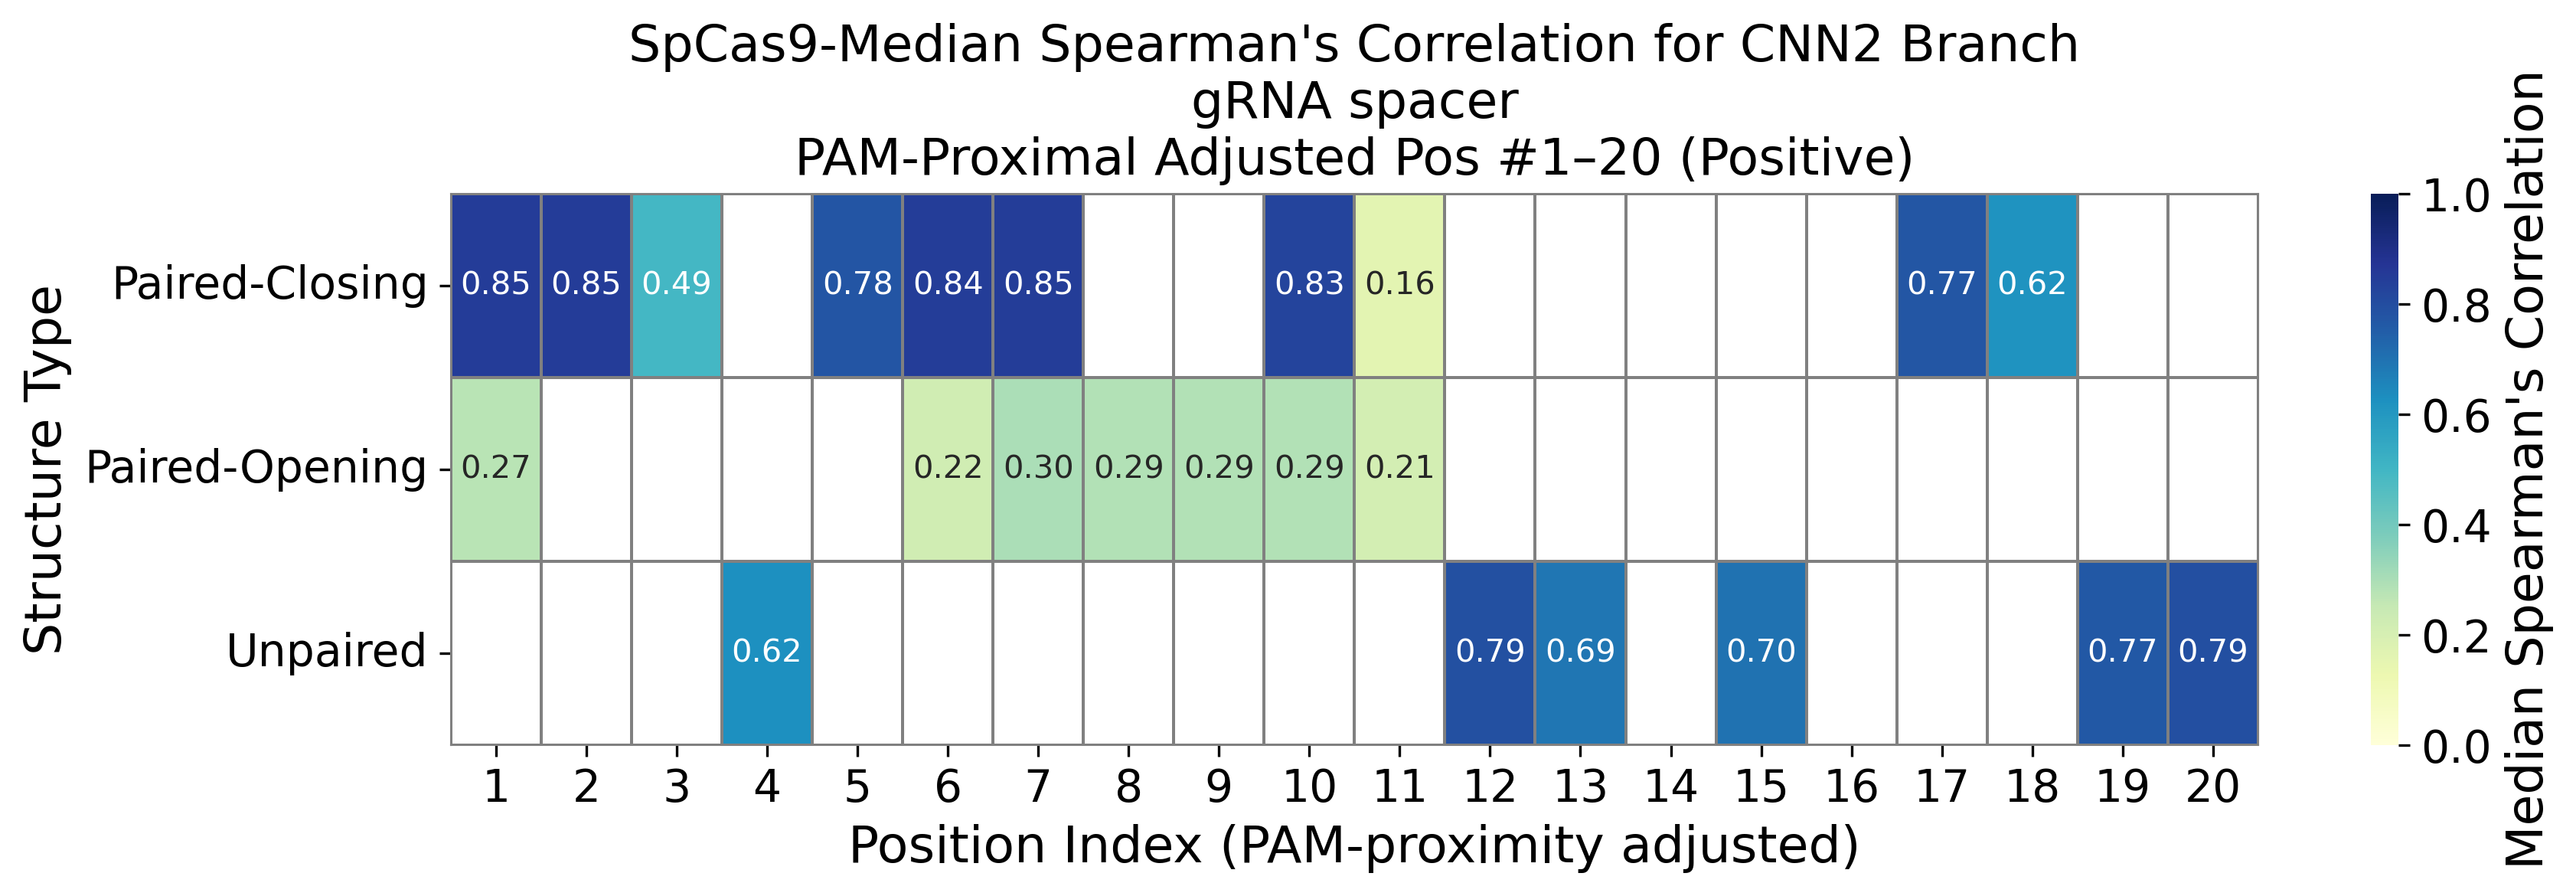

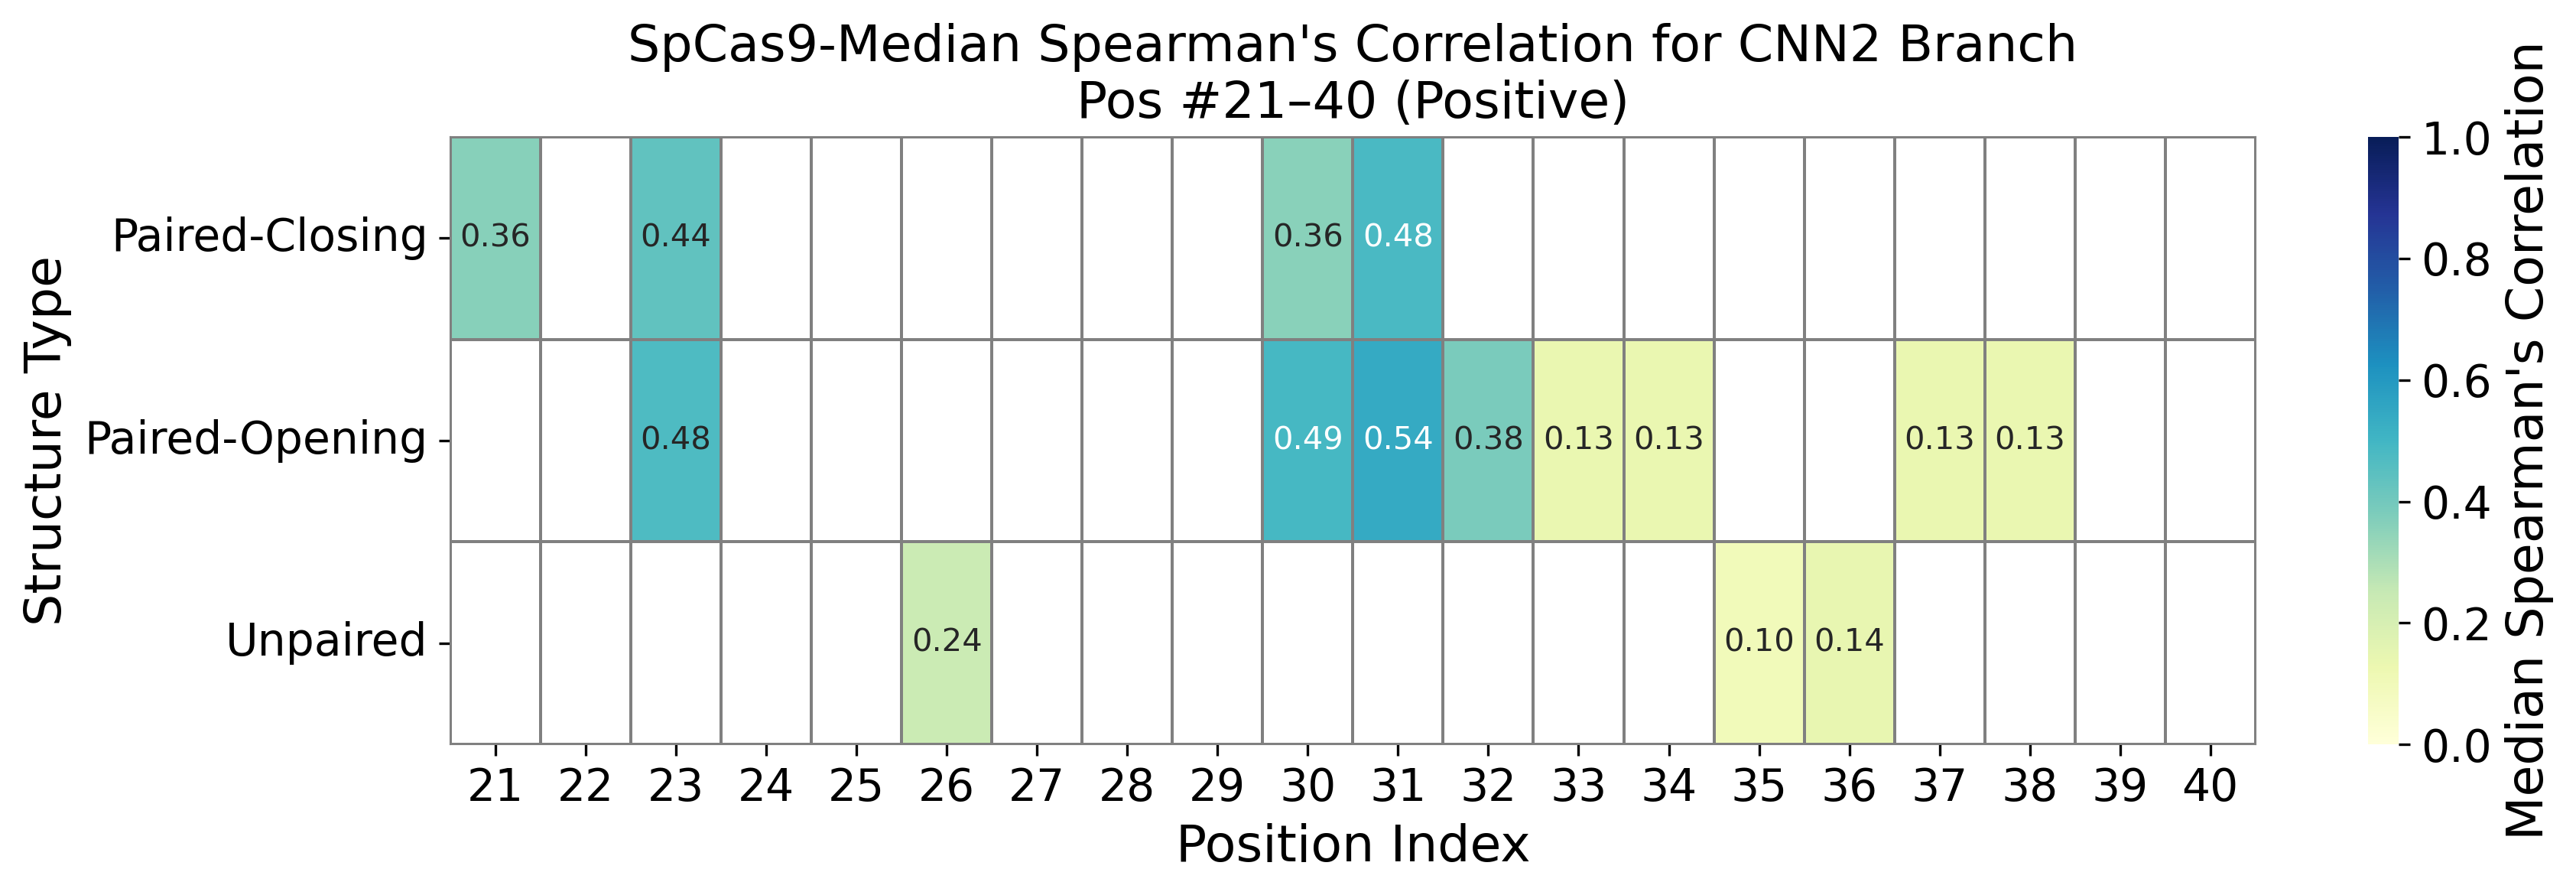

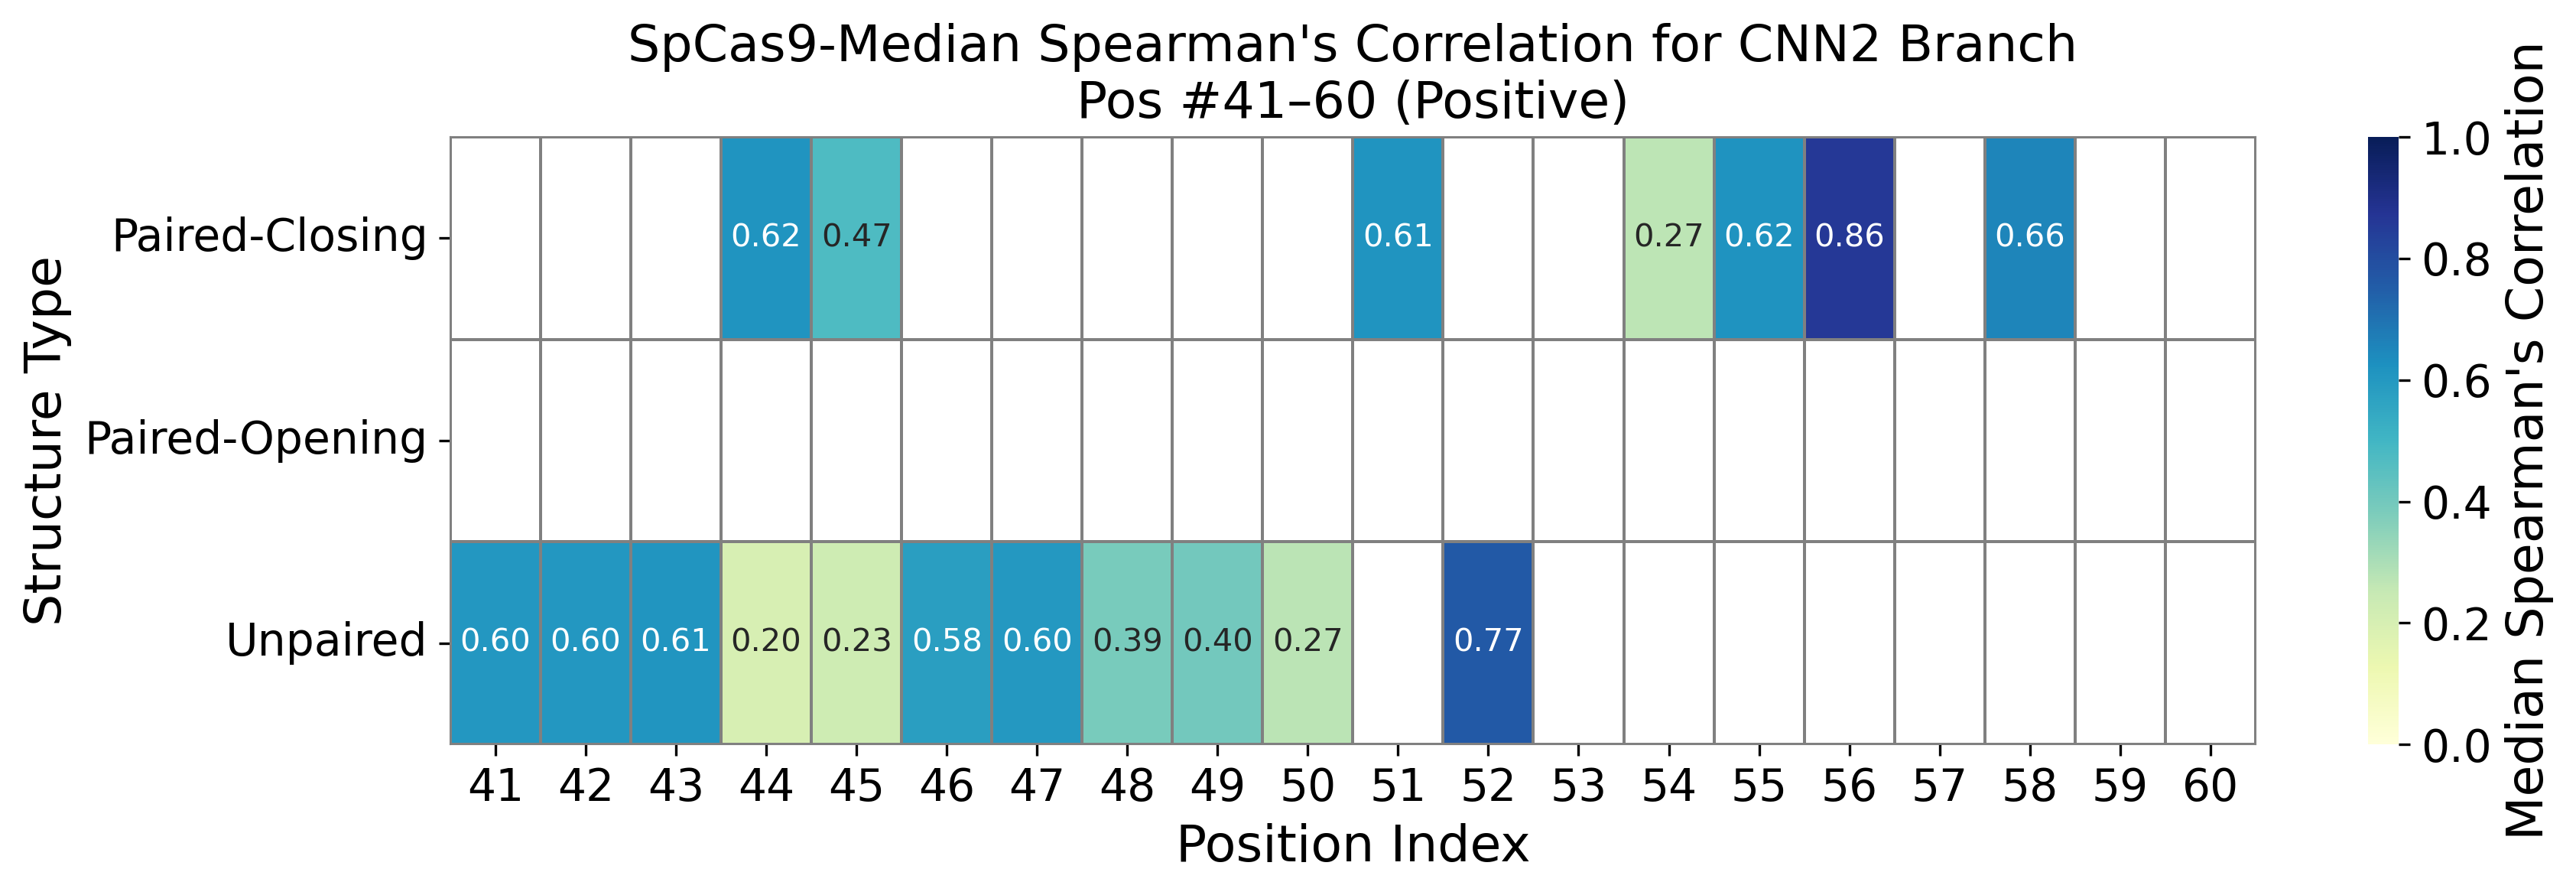

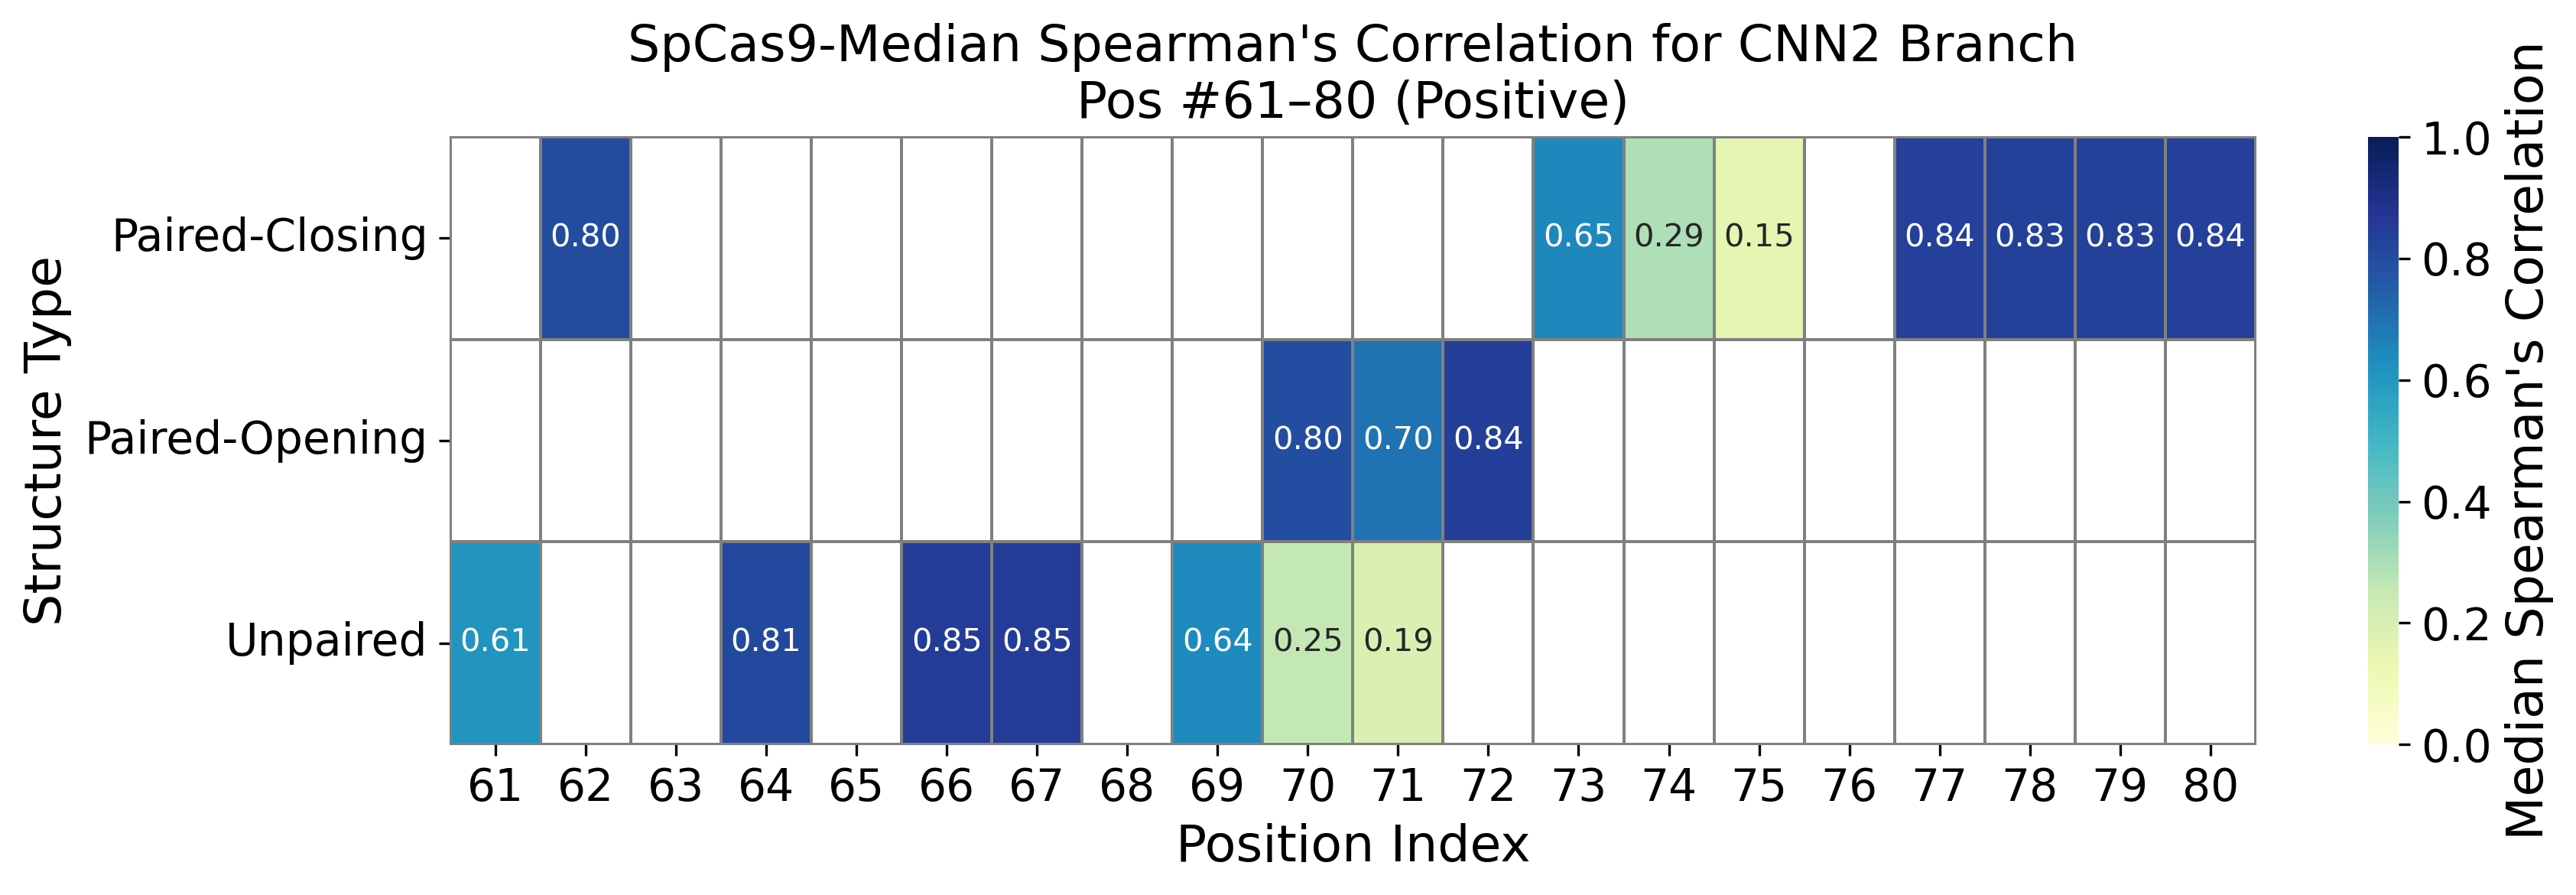

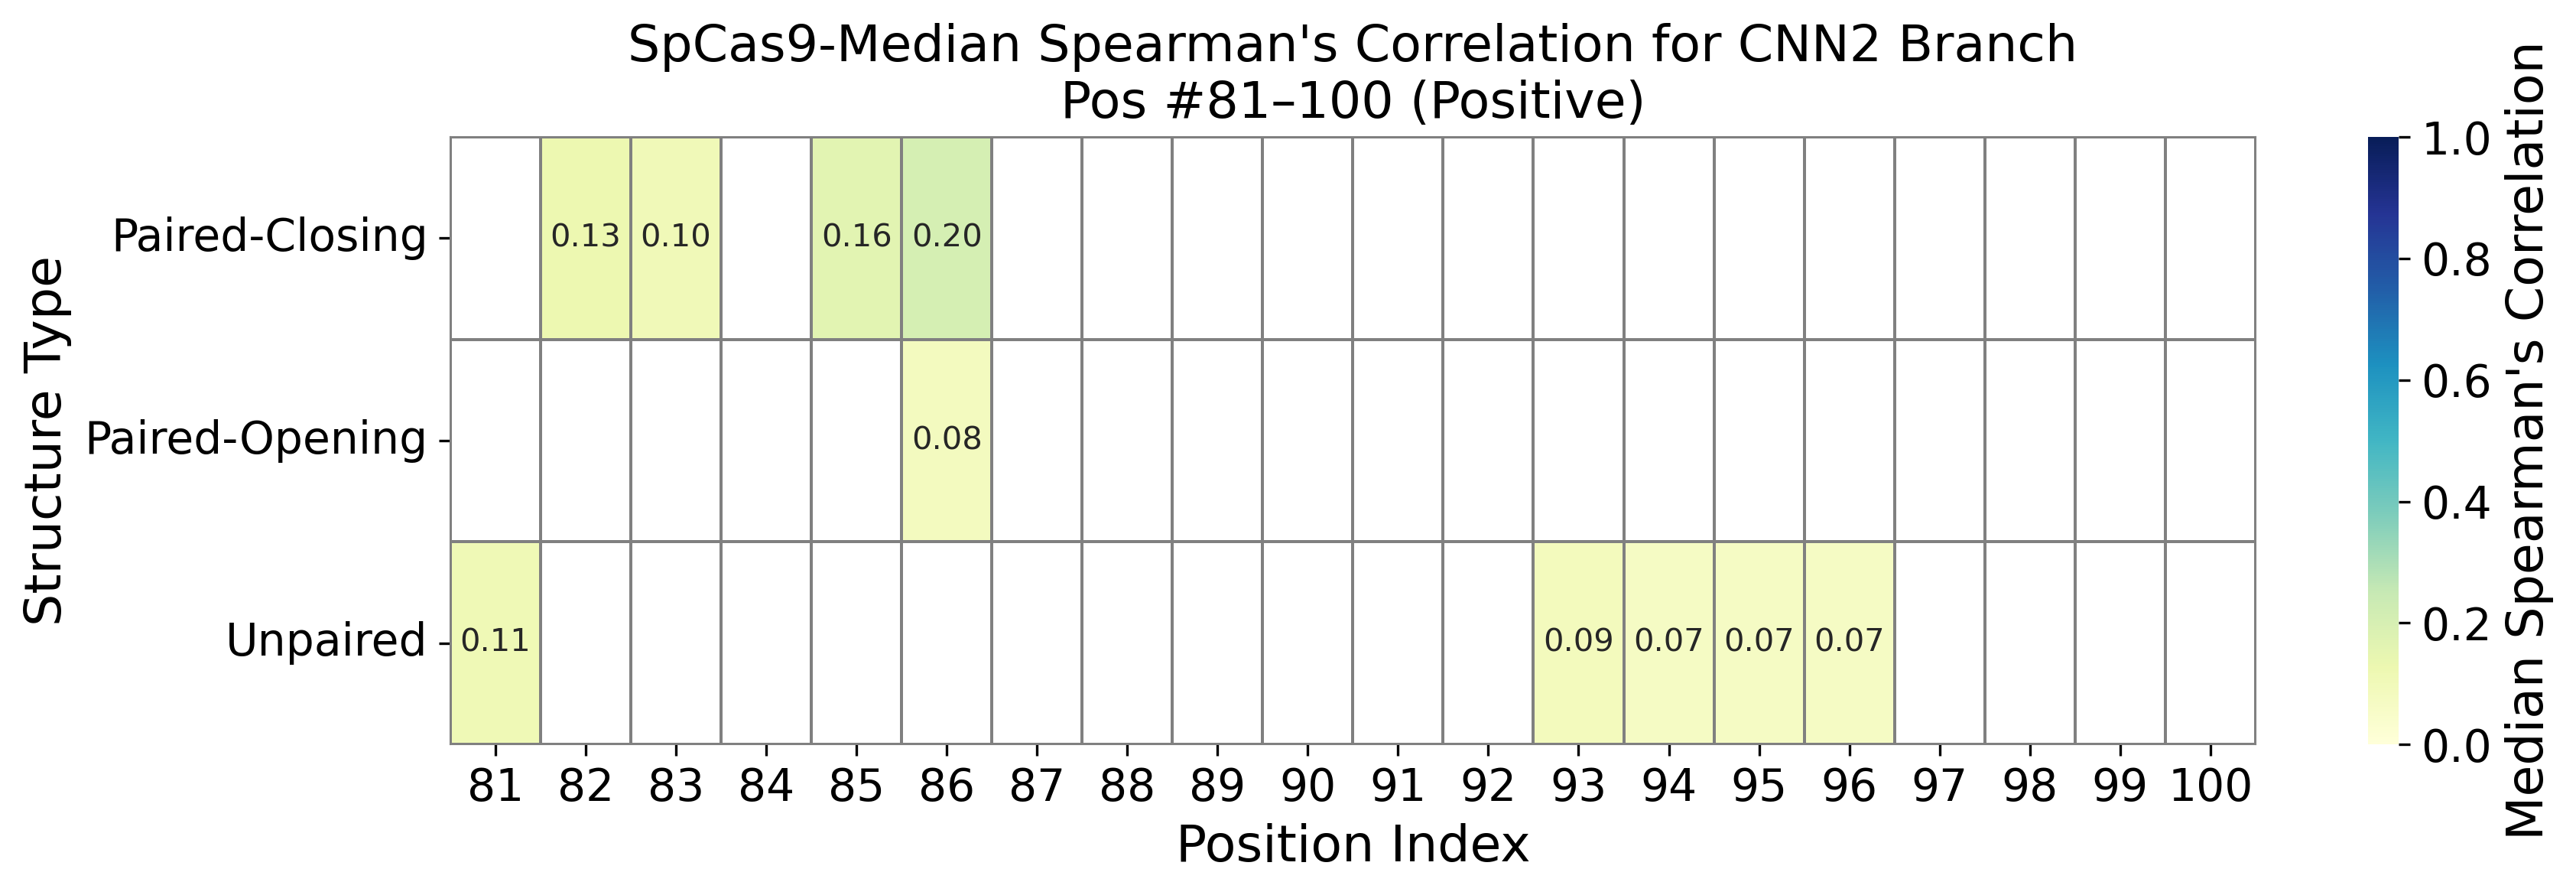

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === Load processed feature list ===
iqr_df = pd.read_csv("features_with_positive_IQR_Specificity_model_cnn2.csv")

# === Extract Pos and Base Type (here Base = sub-feature like Paired, Opening, etc.) ===
iqr_df[['Pos', 'Base']] = iqr_df['Feature'].str.extract(r'Pos(\d+)_(.+)')
iqr_df['Pos'] = iqr_df['Pos'].astype(int)

# === Handle duplicate (Base, Pos) entries by averaging ===
iqr_df_grouped = iqr_df.groupby(['Base', 'Pos'])["Median Spearman Correlation"].mean().reset_index()

# === Pivot to heatmap format ===
heatmap_data = iqr_df_grouped.pivot(index="Base", columns="Pos", values="Median Spearman Correlation")

# Optional: Set fixed row order
row_order = sorted(heatmap_data.index.unique())
heatmap_data = heatmap_data.reindex(row_order)

# Always show positions 1–100
full_pos_range = range(1, 101)
heatmap_data = heatmap_data.reindex(columns=full_pos_range)

# Create mask for missing values
mask = heatmap_data.isna()

# === Create two heatmap panels ===

# Extract and reverse ONLY this block

hm_1_20 = heatmap_data.loc[:, 1:20].copy()

# ---- Swap data of top and middle rows (labels unchanged) ----
row_labels = hm_1_20.index.tolist()

if len(row_labels) >= 2:
    r0, r1 = row_labels[0], row_labels[1]
    hm_1_20.loc[[r0, r1]] = hm_1_20.loc[[r1, r0]].values


hm_1_20 = hm_1_20.iloc[:, ::-1]

fig1, ax1 = plt.subplots(figsize=(12, 4), dpi=300)
hm1 = sns.heatmap(
    hm_1_20,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=hm_1_20.isna(),
    ax=ax1
)

# ---- Fix x-axis: display 1–20 AFTER reversal ----
n_pos = hm_1_20.shape[1]
ax1.set_xticks(np.arange(n_pos) + 0.5)
ax1.set_xticklabels(range(1, n_pos + 1), fontsize=14)

# ---- Y ticks horizontal ----
ax1.tick_params(axis='y', labelrotation=0)

# Borders
for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax1.set_xlabel("Position Index (PAM-proximity adjusted)", fontsize=16)
ax1.set_ylabel("Structure Type", fontsize=16)

ax1.set_title(
    "SpCas9-Median Spearman's Correlation for CNN2 Branch\n"
    'gRNA spacer\n'
    "PAM-Proximal Adjusted Pos #1–20 (Positive)",
    fontsize=16
)


ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar1 = hm1.collections[0].colorbar
cbar1.ax.tick_params(labelsize=14)
cbar1.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()





# Heatmap for positions 21–40
fig2, ax2 = plt.subplots(figsize=(12, 4), dpi=300)
hm2 = sns.heatmap(
    heatmap_data.loc[:, 21:40],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=heatmap_data.loc[:, 21:40].isna(),
    ax=ax2
)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax2.set_xlabel("Position Index", fontsize=16)
ax2.set_ylabel("Structure Type", fontsize=16)
ax2.set_title(
    "SpCas9-Median Spearman's Correlation for CNN2 Branch\n"
    "Pos #21–40 (Positive)",
    fontsize=16
)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar2 = hm2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=14)
cbar2.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()


# Heatmap for positions 41–60
fig2, ax2 = plt.subplots(figsize=(12, 4), dpi=300)
hm2 = sns.heatmap(
    heatmap_data.loc[:, 41:60],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=heatmap_data.loc[:, 41:60].isna(),
    ax=ax2
)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax2.set_xlabel("Position Index", fontsize=16)
ax2.set_ylabel("Structure Type", fontsize=16)
ax2.set_title(
    "SpCas9-Median Spearman's Correlation for CNN2 Branch\n"
    "Pos #41–60 (Positive)",
    fontsize=16
)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar2 = hm2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=14)
cbar2.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()

# Heatmap for positions 61–80
fig2, ax2 = plt.subplots(figsize=(12, 4), dpi=300)
hm2 = sns.heatmap(
    heatmap_data.loc[:, 61:80],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=heatmap_data.loc[:, 61:80].isna(),
    ax=ax2
)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax2.set_xlabel("Position Index", fontsize=16)
ax2.set_ylabel("Structure Type", fontsize=16)
ax2.set_title(
    "SpCas9-Median Spearman's Correlation for CNN2 Branch\n"
    "Pos #61–80 (Positive)",
    fontsize=16
)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar2 = hm2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=14)
cbar2.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()


# Heatmap for positions 81–100
fig2, ax2 = plt.subplots(figsize=(12, 4), dpi=300)
hm2 = sns.heatmap(
    heatmap_data.loc[:, 81:100],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=heatmap_data.loc[:, 81:100].isna(),
    ax=ax2
)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax2.set_xlabel("Position Index", fontsize=16)
ax2.set_ylabel("Structure Type", fontsize=16)
ax2.set_title(
    "SpCas9-Median Spearman's Correlation for CNN2 Branch\n"
    "Pos #81–100 (Positive)",
    fontsize=16
)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar2 = hm2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=14)
cbar2.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()
